# INFEST XII 2026 Data Science — EfficientNet-B0 5-Fold Baseline (Vast.ai RTX 4080S)

Notebook ini mengimplementasikan **baseline yang sudah disepakati** untuk klasifikasi jenis aksara dari segmented text-line image. Metodologi model dan validasinya tidak diubah; notebook hanya disesuaikan untuk **single-GPU NVIDIA RTX 4090** dan struktur folder lokal/Vast.ai.

Metodologi baseline:

- hanya menggunakan **train berlabel resmi** untuk training;
- **ImageNet-pretrained EfficientNet-B0** dengan **full fine-tuning** seluruh backbone;
- **aspect-ratio-preserving resize** ke canvas **128×512** dengan white padding;
- augmentasi dokumen konservatif tanpa horizontal/vertical flip atau rotasi besar;
- **CrossEntropyLoss + label smoothing 0.05**, tanpa class weighting dan weighted sampler;
- **AdamW**, backbone LR `2e-4` dan classifier LR `8e-4`;
- **1 epoch warmup + cosine decay**, FP16 AMP, gradient clipping, early stopping;
- **Stratified 5-Fold CV**, checkpoint terbaik berdasarkan validation **Macro F1**;
- prediksi test = probability average dari lima best checkpoint;
- tidak ada pseudo-labeling, external data, OCR intermediate step, atau manual override.

Struktur folder yang diharapkan:

```text
project/
├── INFEST_XII_EfficientNetB0_5Fold_Baseline_VastAI_RTX4090.ipynb
└── data/
    ├── train.csv
    ├── test.csv
    ├── sample_submission.csv
    └── images/
        ├── train/
        └── test/
```

Semua output akan disimpan ke `./infest_effnetb0_baseline/`. Notebook tidak menggunakan `nn.DataParallel`; seluruh training berjalan pada `cuda:0` agar cocok dengan instance Vast.ai single-GPU.


In [1]:
# ============================================================
# 1. Imports, konfigurasi, dan reproducibility
# ============================================================

import os
import gc
import math
import json
import random
import warnings
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

warnings.filterwarnings('ignore')

# --------------------------
# Reproducibility
# --------------------------
SEED = 42


def seed_everything(seed: int = SEED) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Pertahankan reproducibility baseline. Tidak memakai cudnn.benchmark.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

# --------------------------
# Baseline configuration
# --------------------------
N_SPLITS = 5
IMG_H = 128
IMG_W = 512

# Global batch sengaja dipertahankan dari baseline yang disepakati agar
# optimization dynamics tidak berubah ketika pindah dari Kaggle ke Vast.ai.
TRAIN_BATCH_SIZE = 64
EVAL_BATCH_SIZE = 256  # hanya inference/validation, tidak mengubah training dynamics
NUM_WORKERS = min(8, max(1, os.cpu_count() or 1))

MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
WARMUP_EPOCHS = 1

BACKBONE_LR = 2e-4
HEAD_LR = 8e-4
MIN_LR_RATIO = 0.05
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
GRAD_CLIP_NORM = 1.0

USE_AMP = True
SAVE_FOLD_CHECKPOINTS = True

# Notebook dan folder data berada pada root project yang sama.
PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'infest_effnetb0_baseline'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not torch.cuda.is_available():
    raise RuntimeError(
        'CUDA GPU tidak terdeteksi. Pastikan instance Vast.ai memakai image PyTorch/CUDA '
        'yang mendukung NVIDIA GPU dan driver sudah tersedia.'
    )

# Single-GPU execution. Tidak memakai nn.DataParallel.
DEVICE = torch.device('cuda:0')
torch.cuda.set_device(DEVICE)

# Ada/Tensor-Core friendly. FP16 AMP tetap menjadi precision utama.
if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

GPU_NAME = torch.cuda.get_device_name(0)
GPU_PROPS = torch.cuda.get_device_properties(0)
GPU_VRAM_GB = GPU_PROPS.total_memory / (1024 ** 3)

print(f'Project root   : {PROJECT_ROOT}')
print(f'PyTorch        : {torch.__version__}')
print(f'CUDA runtime   : {torch.version.cuda}')
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'GPU            : {GPU_NAME}')
print(f'VRAM           : {GPU_VRAM_GB:.1f} GB')
print(f'Compute cap.   : {GPU_PROPS.major}.{GPU_PROPS.minor}')
print(f'Workers        : {NUM_WORKERS}')
print(f'Output dir     : {OUTPUT_DIR}')


Project root   : /workspace
PyTorch        : 2.11.0+cu128
CUDA runtime   : 12.8
CUDA available : True
GPU            : NVIDIA GeForce RTX 4090
VRAM           : 23.5 GB
Compute cap.   : 8.9
Workers        : 8
Output dir     : /workspace/infest_effnetb0_baseline


## 2. Dataset discovery dan audit awal

Notebook mencari dataset di folder `./data` relatif terhadap working directory notebook. Struktur utama yang diharapkan adalah `train.csv`, `test.csv`, `sample_submission.csv`, `images/train/`, dan `images/test/`. Jika file berada satu level lebih dalam di dalam `data/`, notebook tetap akan mendeteksinya secara otomatis.

Audit awal memeriksa file yang hilang, file berukuran nol, dan citra yang gagal dibuka. Baris train yang tidak valid dikeluarkan secara otomatis. Citra test yang tidak valid dianggap sebagai error karena setiap baris test wajib memperoleh prediksi.


In [2]:
# ============================================================
# 2. Dataset discovery dan validation
# ============================================================

REQUIRED_FILES = {'train.csv', 'test.csv', 'sample_submission.csv'}


def is_dataset_root(root: Path) -> bool:
    return (
        root.is_dir()
        and all((root / name).is_file() for name in REQUIRED_FILES)
        and (root / 'images' / 'train').is_dir()
        and (root / 'images' / 'test').is_dir()
    )


def find_dataset_root(base_dir: Path) -> Path:
    base_dir = Path(base_dir).resolve()
    if not base_dir.exists():
        raise FileNotFoundError(
            f'Folder dataset tidak ditemukan: {base_dir}\n'
            'Buat folder ./data di root project dan letakkan train.csv, test.csv, '
            'sample_submission.csv, serta folder images/train dan images/test di dalamnya.'
        )

    # Struktur yang direkomendasikan: ./data/{csv, images/...}
    if is_dataset_root(base_dir):
        return base_dir

    # Fallback aman jika dataset diekstrak ke satu subfolder di dalam ./data.
    candidates = []
    for train_csv in base_dir.rglob('train.csv'):
        root = train_csv.parent
        if is_dataset_root(root):
            candidates.append(root)

    candidates = list(dict.fromkeys(candidates))
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) > 1:
        candidates = sorted(candidates, key=lambda p: (p / 'train.csv').stat().st_size, reverse=True)
        print('Beberapa candidate dataset root ditemukan. Menggunakan:')
        for p in candidates:
            print(f'  - {p}')
        return candidates[0]

    raise FileNotFoundError(
        f'Struktur dataset INFEST tidak ditemukan di {base_dir}.\n'
        'Struktur yang diharapkan: data/train.csv, data/test.csv, '
        'data/sample_submission.csv, data/images/train/, data/images/test/.'
    )


DATA_ROOT = find_dataset_root(DATA_DIR)
TRAIN_IMG_DIR = DATA_ROOT / 'images' / 'train'
TEST_IMG_DIR = DATA_ROOT / 'images' / 'test'

train_df = pd.read_csv(DATA_ROOT / 'train.csv')
test_df = pd.read_csv(DATA_ROOT / 'test.csv')
sample_submission = pd.read_csv(DATA_ROOT / 'sample_submission.csv')

assert list(train_df.columns) == ['image_id', 'label'], f'Kolom train.csv tidak sesuai: {train_df.columns.tolist()}'
assert list(test_df.columns) == ['image_id'], f'Kolom test.csv tidak sesuai: {test_df.columns.tolist()}'
assert list(sample_submission.columns) == ['image_id', 'label'], 'Format sample_submission.csv tidak sesuai.'
assert train_df['image_id'].is_unique, 'image_id train harus unik.'
assert test_df['image_id'].is_unique, 'image_id test harus unik.'
assert set(sample_submission['image_id']) == set(test_df['image_id']), 'image_id sample submission tidak identik dengan test.csv.'

print(f'Data root       : {DATA_ROOT}')
print(f'Train rows raw  : {len(train_df):,}')
print(f'Test rows       : {len(test_df):,}')
print('\nDistribusi kelas train raw:')
print(train_df['label'].value_counts().sort_index())


def validate_image_file(path: Path):
    if not path.exists():
        return False, 'missing'
    if path.stat().st_size == 0:
        return False, 'zero_byte'
    try:
        with Image.open(path) as img:
            img.verify()
        return True, 'ok'
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        return False, type(exc).__name__


def audit_dataframe_images(df: pd.DataFrame, image_dir: Path) -> pd.DataFrame:
    bad = []
    for image_id in df['image_id'].tolist():
        ok, reason = validate_image_file(image_dir / image_id)
        if not ok:
            bad.append({'image_id': image_id, 'reason': reason})
    return pd.DataFrame(bad, columns=['image_id', 'reason'])


bad_train = audit_dataframe_images(train_df, TRAIN_IMG_DIR)
bad_test = audit_dataframe_images(test_df, TEST_IMG_DIR)

if len(bad_train):
    print('\nTrain image invalid yang dikeluarkan:')
    display(bad_train)
    train_df = train_df.loc[~train_df['image_id'].isin(bad_train['image_id'])].reset_index(drop=True)
else:
    print('\nTidak ada train image invalid.')

if len(bad_test):
    display(bad_test)
    raise RuntimeError('Terdapat test image invalid. Submission lengkap tidak dapat dibuat dengan aman.')

CLASSES = sorted(train_df['label'].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(CLASSES)}
IDX_TO_CLASS = {i: label for label, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASSES)

train_df['target'] = train_df['label'].map(CLASS_TO_IDX).astype(int)

print(f'\nTrain rows valid: {len(train_df):,}')
print(f'Classes ({NUM_CLASSES}): {CLASSES}')
print('\nDistribusi kelas train valid:')
print(train_df['label'].value_counts().reindex(CLASSES))

assert NUM_CLASSES == 7, f'Dataset yang ditemukan memiliki {NUM_CLASSES} kelas, bukan 7 kelas INFEST yang diharapkan.'
assert train_df['target'].notna().all()


Data root       : /workspace/data
Train rows raw  : 4,468
Test rows       : 1,118

Distribusi kelas train raw:
label
bali       367
jawa       653
jawi       814
lampung    823
lontara    382
pegon      771
sunda      658
Name: count, dtype: int64

Train image invalid yang dikeluarkan:


,image_id,reason
0,mPmaODVU.png,zero_byte



Train rows valid: 4,467
Classes (7): ['bali', 'jawa', 'jawi', 'lampung', 'lontara', 'pegon', 'sunda']

Distribusi kelas train valid:
label
bali       367
jawa       653
jawi       814
lampung    822
lontara    382
pegon      771
sunda      658
Name: count, dtype: int64



## 3. Preprocessing line-preserving dan augmentasi konservatif

Setiap gambar merupakan potongan baris teks dengan aspect ratio yang sangat beragam. Karena itu, gambar **tidak di-stretch menjadi 224×224**. Fungsi `Letterbox` mempertahankan aspect ratio, mengecilkan gambar hanya jika diperlukan agar seluruh baris muat dalam canvas 128×512, lalu menambahkan padding putih secara simetris.

Augmentasi training dibatasi pada transformasi yang masih masuk akal untuk citra dokumen: rotasi kecil, translasi kecil, scale kecil, perubahan brightness/contrast ringan, dan blur ringan. Tidak ada flip atau rotasi besar karena transformasi tersebut dapat mengubah struktur aksara secara tidak natural.


In [3]:

# ============================================================
# 3. Transform dan Dataset
# ============================================================

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class Letterbox:
    """Resize dengan aspect ratio tetap dan center-pad ke canvas putih."""

    def __init__(self, size=(IMG_H, IMG_W), fill=(255, 255, 255)):
        self.out_h, self.out_w = size
        self.fill = fill

    def __call__(self, image: Image.Image) -> Image.Image:
        image = image.convert('RGB')
        w, h = image.size
        if w <= 0 or h <= 0:
            raise ValueError(f'Ukuran gambar tidak valid: {(w, h)}')

        scale = min(self.out_w / w, self.out_h / h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))

        image = image.resize((new_w, new_h), resample=Image.Resampling.BICUBIC)
        canvas = Image.new('RGB', (self.out_w, self.out_h), self.fill)
        left = (self.out_w - new_w) // 2
        top = (self.out_h - new_h) // 2
        canvas.paste(image, (left, top))
        return canvas


train_transform = T.Compose([
    Letterbox((IMG_H, IMG_W)),
    T.RandomAffine(
        degrees=2.5,
        translate=(0.02, 0.03),
        scale=(0.95, 1.05),
        interpolation=T.InterpolationMode.BILINEAR,
        fill=(255, 255, 255),
    ),
    T.RandomApply([
        T.ColorJitter(brightness=0.08, contrast=0.10),
    ], p=0.30),
    T.RandomApply([
        T.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8)),
    ], p=0.10),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

valid_transform = T.Compose([
    Letterbox((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class AksaraDataset(Dataset):
    def __init__(self, df: pd.DataFrame, image_dir: Path, transform, with_target: bool = True):
        self.df = df.reset_index(drop=True).copy()
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.with_target = with_target

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = self.image_dir / row['image_id']
        with Image.open(path) as image:
            image = image.convert('RGB')
            image = self.transform(image)

        if self.with_target:
            return image, int(row['target'])
        return image


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_loader(dataset, batch_size, shuffle, seed, drop_last=False):
    generator = torch.Generator()
    generator.manual_seed(seed)
    kwargs = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=drop_last,
        worker_init_fn=seed_worker,
        generator=generator,
    )
    if NUM_WORKERS > 0:
        kwargs.update(persistent_workers=True, prefetch_factor=2)
    return DataLoader(**kwargs)



## 4. EfficientNet-B0 full fine-tuning dan training utilities

Backbone menggunakan official `torchvision` EfficientNet-B0 pretrained ImageNet. Seluruh parameter backbone tetap trainable. Classifier terakhir diganti menjadi 7 kelas.

Optimizer menggunakan dua parameter group:

- backbone: `2e-4`
- classifier: `8e-4`

Loss menggunakan Cross Entropy dengan label smoothing `0.05`, tanpa class weight. Scheduler memakai satu epoch warmup lalu cosine decay hingga 5% dari base learning rate. Training memakai AMP, gradient clipping, dan checkpoint terbaik berdasarkan Macro F1 validation.


In [4]:
# ============================================================
# 4. Model, optimizer, scheduler, training utilities
# ============================================================

OFFICIAL_TORCHVISION_WEIGHT_NAME = 'efficientnet_b0_rwightman-7f5810bc.pth'


def find_local_pretrained_weight():
    """Fallback jika official torchvision weight sudah tersedia sebagai file lokal."""
    search_roots = [PROJECT_ROOT, DATA_DIR]
    for root in search_roots:
        if root.exists():
            exact = list(root.rglob(OFFICIAL_TORCHVISION_WEIGHT_NAME))
            if exact:
                return exact[0]
    return None


def build_model(num_classes: int):
    try:
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    except Exception as exc:
        local_weight = find_local_pretrained_weight()
        if local_weight is None:
            raise RuntimeError(
                'Gagal memuat ImageNet pretrained EfficientNet-B0. '
                'Pastikan instance Vast.ai memiliki akses internet untuk mengunduh official torchvision weights, '
                'atau letakkan file EfficientNet-B0 official .pth di root project/data.'
            ) from exc
        print(f'Memuat pretrained weight lokal: {local_weight}')
        model = efficientnet_b0(weights=None)
        state = torch.load(local_weight, map_location='cpu')
        model.load_state_dict(state, strict=True)

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def unwrap_model(model):
    # Baseline Vast.ai berjalan single-GPU, tetapi helper ini tetap toleran terhadap wrapper.
    return model.module if hasattr(model, 'module') else model


def build_optimizer(model):
    base_model = unwrap_model(model)
    backbone_params = []
    head_params = []

    for name, param in base_model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith('classifier.'):
            head_params.append(param)
        else:
            backbone_params.append(param)

    if not backbone_params or not head_params:
        raise RuntimeError('Parameter group backbone/head tidak terbentuk dengan benar.')

    optimizer = AdamW(
        [
            {'params': backbone_params, 'lr': BACKBONE_LR},
            {'params': head_params, 'lr': HEAD_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    return optimizer


def build_scheduler(optimizer, steps_per_epoch: int):
    total_steps = max(1, MAX_EPOCHS * steps_per_epoch)
    warmup_steps = max(1, WARMUP_EPOCHS * steps_per_epoch)

    def lr_lambda(step):
        if step < warmup_steps:
            return max(1e-3, (step + 1) / warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        progress = min(max(progress, 0.0), 1.0)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return MIN_LR_RATIO + (1.0 - MIN_LR_RATIO) * cosine

    return LambdaLR(optimizer, lr_lambda=lr_lambda)


def amp_context():
    """FP16 autocast pada CUDA; tetap kompatibel dengan PyTorch Kaggle modern."""
    if not USE_AMP:
        return nullcontext()
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'autocast'):
        return torch.amp.autocast(device_type='cuda', dtype=torch.float16)
    return torch.cuda.amp.autocast(dtype=torch.float16)


def make_grad_scaler():
    """GradScaler dengan fallback API untuk kompatibilitas lintas versi PyTorch 2.x."""
    if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
        try:
            return torch.amp.GradScaler('cuda', enabled=USE_AMP)
        except TypeError:
            pass
    return torch.cuda.amp.GradScaler(enabled=USE_AMP)


def move_images_to_device(images):
    # Layout NCHW contiguous standar, stabil untuk single-GPU + FP16 AMP.
    return images.to(DEVICE, non_blocking=True).contiguous()


def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for images, targets in loader:
        images = move_images_to_device(images)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with amp_context():
            logits = model(images)
            loss = criterion(logits, targets)

        if not torch.isfinite(loss):
            raise FloatingPointError(f'Loss non-finite terdeteksi: {loss.detach().item()}')

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        bs = targets.size(0)
        running_loss += loss.detach().item() * bs
        n_samples += bs

    return running_loss / max(1, n_samples)


@torch.inference_mode()
def predict_loader(model, loader, with_targets=True):
    model.eval()
    probs_all = []
    targets_all = []

    for batch in loader:
        if with_targets:
            images, targets = batch
            targets_all.append(targets.numpy())
        else:
            images = batch

        images = move_images_to_device(images)
        with amp_context():
            logits = model(images)
        probs = torch.softmax(logits.float(), dim=1).cpu().numpy()
        probs_all.append(probs)

    if not probs_all:
        raise RuntimeError('DataLoader kosong; tidak ada batch untuk diprediksi.')

    probs_all = np.concatenate(probs_all, axis=0)
    if with_targets:
        targets_all = np.concatenate(targets_all, axis=0)
        return probs_all, targets_all
    return probs_all


def validation_metrics(y_true, probs):
    y_pred = probs.argmax(axis=1)
    return {
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
    }


def save_checkpoint(path: Path, model, fold: int, epoch: int, score: float):
    payload = {
        'model_state_dict': unwrap_model(model).state_dict(),
        'fold': fold,
        'epoch': epoch,
        'macro_f1': score,
        'classes': CLASSES,
        'img_h': IMG_H,
        'img_w': IMG_W,
    }
    torch.save(payload, path)


def load_checkpoint_into_model(path: Path, model):
    try:
        checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        checkpoint = torch.load(path, map_location='cpu')
    if checkpoint.get('classes') != CLASSES:
        raise RuntimeError('Urutan kelas checkpoint tidak sama dengan konfigurasi saat ini.')
    unwrap_model(model).load_state_dict(checkpoint['model_state_dict'], strict=True)
    return checkpoint



## 5. Stratified 5-Fold training

Validation menggunakan `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` agar proporsi tujuh kelas tetap terjaga pada setiap fold. Setiap fold dilatih secara independen, dan checkpoint terbaik ditentukan hanya berdasarkan Macro F1 validation.

Setelah checkpoint terbaik dimuat kembali, notebook menyimpan probabilitas OOF untuk validation fold dan probabilitas test. Lima probabilitas test kemudian dirata-ratakan. Tidak ada informasi test yang digunakan untuk memperbarui model.


In [5]:

# ============================================================
# 5. Five-fold training, OOF, dan test prediction
# ============================================================

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_assignment = np.full(len(train_df), -1, dtype=np.int16)
oof_probs = np.zeros((len(train_df), NUM_CLASSES), dtype=np.float32)
test_prob_sum = np.zeros((len(test_df), NUM_CLASSES), dtype=np.float32)
fold_metrics_rows = []

# Test order mengikuti test.csv. sample_submission akan di-merge pada tahap akhir.
test_dataset = AksaraDataset(test_df, TEST_IMG_DIR, valid_transform, with_target=False)
test_loader = make_loader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    seed=SEED + 10_000,
)

for fold, (train_idx, valid_idx) in enumerate(skf.split(train_df, train_df['target']), start=1):
    print('\n' + '=' * 80)
    print(f'FOLD {fold}/{N_SPLITS}')
    print('=' * 80)

    seed_everything(SEED + fold)
    fold_assignment[valid_idx] = fold

    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_valid_df = train_df.iloc[valid_idx].reset_index(drop=True)

    print(f'Train: {len(fold_train_df):,} | Valid: {len(fold_valid_df):,}')

    train_dataset = AksaraDataset(fold_train_df, TRAIN_IMG_DIR, train_transform, with_target=True)
    valid_dataset = AksaraDataset(fold_valid_df, TRAIN_IMG_DIR, valid_transform, with_target=True)

    train_loader = make_loader(
        train_dataset,
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=True,
        seed=SEED + fold,
    )
    valid_loader = make_loader(
        valid_dataset,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
        seed=SEED + 1_000 + fold,
    )

    model = build_model(NUM_CLASSES).to(DEVICE)
    print(f'Single-GPU training pada {GPU_NAME} | AMP={USE_AMP} | batch={TRAIN_BATCH_SIZE}')

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = build_optimizer(model)
    scheduler = build_scheduler(optimizer, steps_per_epoch=len(train_loader))
    scaler = make_grad_scaler()

    checkpoint_path = OUTPUT_DIR / f'fold_{fold}_best.pth'
    history = []
    best_score = -np.inf
    best_epoch = -1
    epochs_without_improvement = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, scaler)
        valid_probs, valid_targets = predict_loader(model, valid_loader, with_targets=True)
        metrics = validation_metrics(valid_targets, valid_probs)

        current_lrs = [group['lr'] for group in optimizer.param_groups]
        row = {
            'fold': fold,
            'epoch': epoch,
            'train_loss': train_loss,
            'valid_macro_f1': metrics['macro_f1'],
            'valid_accuracy': metrics['accuracy'],
            'backbone_lr': current_lrs[0],
            'head_lr': current_lrs[1],
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"loss={train_loss:.5f} | "
            f"val_macro_f1={metrics['macro_f1']:.6f} | "
            f"val_acc={metrics['accuracy']:.6f}"
        )

        if metrics['macro_f1'] > best_score + 1e-7:
            best_score = metrics['macro_f1']
            best_epoch = epoch
            epochs_without_improvement = 0
            save_checkpoint(checkpoint_path, model, fold, epoch, best_score)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f'Early stopping pada epoch {epoch}. Best epoch={best_epoch}, Macro F1={best_score:.6f}')
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / f'history_fold_{fold}.csv', index=False)

    # Muat checkpoint terbaik, kemudian prediksi validation dan test secara deterministik.
    best_ckpt = load_checkpoint_into_model(checkpoint_path, model)
    print(f"Best checkpoint fold {fold}: epoch={best_ckpt['epoch']}, Macro F1={best_ckpt['macro_f1']:.6f}")

    valid_probs, valid_targets = predict_loader(model, valid_loader, with_targets=True)
    valid_pred = valid_probs.argmax(axis=1)
    fold_macro_f1 = f1_score(valid_targets, valid_pred, average='macro', zero_division=0)
    fold_accuracy = accuracy_score(valid_targets, valid_pred)

    oof_probs[valid_idx] = valid_probs.astype(np.float32)
    test_fold_probs = predict_loader(model, test_loader, with_targets=False)
    test_prob_sum += test_fold_probs.astype(np.float32)

    fold_metrics_rows.append({
        'fold': fold,
        'best_epoch': int(best_ckpt['epoch']),
        'macro_f1': fold_macro_f1,
        'accuracy': fold_accuracy,
        'n_train': len(train_idx),
        'n_valid': len(valid_idx),
    })

    if not SAVE_FOLD_CHECKPOINTS:
        checkpoint_path.unlink(missing_ok=True)

    # Lepaskan resource fold sebelum fold berikutnya.
    del model, optimizer, scheduler, scaler
    del train_loader, valid_loader, train_dataset, valid_dataset
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(DEVICE)

assert (fold_assignment > 0).all(), 'Ada baris train yang tidak memperoleh fold assignment.'
assert np.isfinite(oof_probs).all(), 'OOF probabilities mengandung nilai non-finite.'
assert np.allclose(oof_probs.sum(axis=1), 1.0, atol=1e-3), 'OOF probabilities tidak ter-normalisasi.'

fold_metrics_df = pd.DataFrame(fold_metrics_rows)
fold_metrics_df.to_csv(OUTPUT_DIR / 'fold_metrics.csv', index=False)

test_probs = test_prob_sum / N_SPLITS
assert np.isfinite(test_probs).all()
assert np.allclose(test_probs.sum(axis=1), 1.0, atol=1e-3)

display(fold_metrics_df)
print(f"Mean fold Macro F1: {fold_metrics_df['macro_f1'].mean():.6f} ± {fold_metrics_df['macro_f1'].std(ddof=1):.6f}")



FOLD 1/5
Train: 3,573 | Valid: 894
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 14.3MB/s]


Single-GPU training pada NVIDIA GeForce RTX 4090 | AMP=True | batch=64
Epoch 01/20 | loss=1.25514 | val_macro_f1=0.884228 | val_acc=0.880313
Epoch 02/20 | loss=0.41738 | val_macro_f1=0.964597 | val_acc=0.960850
Epoch 03/20 | loss=0.33360 | val_macro_f1=0.976491 | val_acc=0.973154
Epoch 04/20 | loss=0.30204 | val_macro_f1=0.979777 | val_acc=0.977629
Epoch 05/20 | loss=0.30071 | val_macro_f1=0.978184 | val_acc=0.975391
Epoch 06/20 | loss=0.28156 | val_macro_f1=0.985035 | val_acc=0.983221
Epoch 07/20 | loss=0.27349 | val_macro_f1=0.984977 | val_acc=0.983221
Epoch 08/20 | loss=0.26777 | val_macro_f1=0.986968 | val_acc=0.985459
Epoch 09/20 | loss=0.26990 | val_macro_f1=0.983419 | val_acc=0.983221
Epoch 10/20 | loss=0.26569 | val_macro_f1=0.985142 | val_acc=0.983221
Epoch 11/20 | loss=0.26620 | val_macro_f1=0.987756 | val_acc=0.986577
Epoch 12/20 | loss=0.26305 | val_macro_f1=0.985245 | val_acc=0.983221
Epoch 13/20 | loss=0.26221 | val_macro_f1=0.984999 | val_acc=0.983221
Epoch 14/20 | loss=

,fold,best_epoch,macro_f1,accuracy,n_train,n_valid
0,1,11,0.987756,0.986577,3573,894
1,2,8,0.985342,0.984340,3573,894
2,3,17,0.988441,0.987682,3574,893
3,4,7,0.981965,0.978723,3574,893
4,5,12,0.981154,0.978723,3574,893


Mean fold Macro F1: 0.984932 ± 0.003299



## 6. OOF evaluation

OOF prediction memberikan estimasi validation yang lebih stabil daripada satu holdout karena setiap citra menjadi validation tepat satu kali. Bagian ini menghasilkan:

- overall OOF Macro F1 dan accuracy;
- F1 per kelas dan classification report;
- confusion matrix;
- `oof_predictions.csv` lengkap dengan probabilitas tujuh kelas;
- `fold_metrics.csv` dan history setiap fold.


OOF Macro F1 : 0.984918
OOF Accuracy : 0.983210


,precision,recall,f1-score,support
bali,0.991870,0.997275,0.994565,367.00000
jawa,0.998377,0.941807,0.969267,653.00000
jawi,0.952324,0.981572,0.966727,814.00000
lampung,0.995157,1.000000,0.997573,822.00000
lontara,1.000000,0.994764,0.997375,382.00000
pegon,0.975484,0.980545,0.978008,771.00000
sunda,0.987915,0.993921,0.990909,658.00000
accuracy,0.983210,0.983210,0.983210,0.98321
macro avg,0.985875,0.984269,0.984918,4467.00000
weighted avg,0.983504,0.983210,0.983192,4467.00000


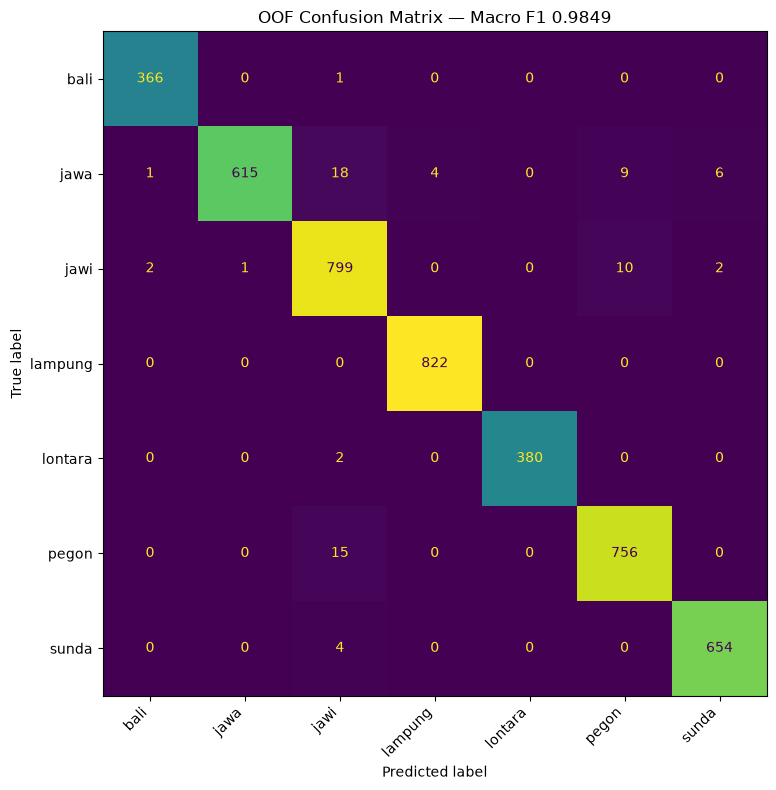

Artifacts OOF tersimpan di: /workspace/infest_effnetb0_baseline


In [6]:

# ============================================================
# 6. OOF evaluation dan artifacts
# ============================================================

oof_pred = oof_probs.argmax(axis=1)
y_true = train_df['target'].to_numpy()

oof_macro_f1 = f1_score(y_true, oof_pred, average='macro', zero_division=0)
oof_accuracy = accuracy_score(y_true, oof_pred)

print(f'OOF Macro F1 : {oof_macro_f1:.6f}')
print(f'OOF Accuracy : {oof_accuracy:.6f}')

report_dict = classification_report(
    y_true,
    oof_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=CLASSES,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(OUTPUT_DIR / 'classification_report_oof.csv')
display(report_df)

cm = confusion_matrix(y_true, oof_pred, labels=np.arange(NUM_CLASSES))
cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
cm_df.to_csv(OUTPUT_DIR / 'confusion_matrix_oof.csv')

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, values_format='d', colorbar=False)
ax.set_title(f'OOF Confusion Matrix — Macro F1 {oof_macro_f1:.4f}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_oof.png', dpi=160, bbox_inches='tight')
plt.show()

# Simpan OOF probabilities dan metadata fold.
oof_df = train_df[['image_id', 'label']].copy()
oof_df['fold'] = fold_assignment
oof_df['pred_label'] = [IDX_TO_CLASS[i] for i in oof_pred]
oof_df['correct'] = (oof_df['label'] == oof_df['pred_label']).astype(int)
for i, cls in enumerate(CLASSES):
    oof_df[f'prob_{cls}'] = oof_probs[:, i]

oof_df.to_csv(OUTPUT_DIR / 'oof_predictions.csv', index=False)

oof_summary = {
    'model': 'torchvision_efficientnet_b0_imagenet1k_v1_full_finetune',
    'n_train_valid_images': int(len(train_df)),
    'n_test_images': int(len(test_df)),
    'n_splits': N_SPLITS,
    'classes': CLASSES,
    'input_size': [IMG_H, IMG_W],
    'oof_macro_f1': float(oof_macro_f1),
    'oof_accuracy': float(oof_accuracy),
    'fold_macro_f1_mean': float(fold_metrics_df['macro_f1'].mean()),
    'fold_macro_f1_std': float(fold_metrics_df['macro_f1'].std(ddof=1)),
    'seed': SEED,
}
with open(OUTPUT_DIR / 'oof_summary.json', 'w') as f:
    json.dump(oof_summary, f, indent=2)

print(f'Artifacts OOF tersimpan di: {OUTPUT_DIR}')



## 7. Final submission

Probabilitas test dari lima checkpoint terbaik dirata-ratakan. Label submission dipilih dengan `argmax` dari probabilitas ensemble tersebut. File akhir mengikuti **urutan `sample_submission.csv`** dan tidak mengubah prediksi secara manual.


In [7]:

# ============================================================
# 7. Submission dari direct model output
# ============================================================

test_pred_idx = test_probs.argmax(axis=1)
test_pred_labels = np.array([IDX_TO_CLASS[i] for i in test_pred_idx])

pred_df = pd.DataFrame({
    'image_id': test_df['image_id'].values,
    'label': test_pred_labels,
})

# Ikuti urutan sample_submission tanpa menggunakan placeholder label di dalamnya.
submission = sample_submission[['image_id']].merge(pred_df, on='image_id', how='left', validate='one_to_one')
assert len(submission) == len(sample_submission)
assert submission['label'].notna().all()
assert set(submission['label']).issubset(set(CLASSES))

submission_path = OUTPUT_DIR / 'submission_effnetb0_5fold.csv'
submission.to_csv(submission_path, index=False)

# Simpan probabilitas test untuk audit/reproducibility. File ini tidak dipakai untuk training ulang.
test_probs_df = test_df[['image_id']].copy()
for i, cls in enumerate(CLASSES):
    test_probs_df[f'prob_{cls}'] = test_probs[:, i]
test_probs_df['pred_label'] = test_pred_labels
test_probs_df.to_csv(OUTPUT_DIR / 'test_probabilities.csv', index=False)

print(f'Submission tersimpan: {submission_path}')
print(f'Rows: {len(submission):,}')
print('\nDistribusi prediksi test:')
print(submission['label'].value_counts().reindex(CLASSES, fill_value=0))
display(submission.head(10))


Submission tersimpan: /workspace/infest_effnetb0_baseline/submission_effnetb0_5fold.csv
Rows: 1,118

Distribusi prediksi test:
label
bali        92
jawa       167
jawi       213
lampung    200
lontara     97
pegon      189
sunda      160
Name: count, dtype: int64


,image_id,label
0,AQmumubg.png,lampung
1,nbXfeFmw.png,jawi
2,mUdL9acm.png,jawi
3,FgSrN0Ad.png,pegon
4,n7xv3e7m.png,lontara
5,hghJ1EVc.png,pegon
6,ZIj1zy8n.png,jawi
7,iwgur6Mj.png,jawa
8,teMl3L2a.png,lontara
9,KvAF3kyn.png,pegon


## 8. Ringkasan file keluaran

Setelah notebook selesai dijalankan, folder `./infest_effnetb0_baseline/` berisi validation artifacts, lima best checkpoint, probabilitas test, dan submission. File `submission_effnetb0_5fold.csv` adalah file yang dapat dikirim ke Kaggle.


In [8]:

# ============================================================
# 8. Final artifact check
# ============================================================

expected_files = [
    'fold_metrics.csv',
    'classification_report_oof.csv',
    'confusion_matrix_oof.csv',
    'confusion_matrix_oof.png',
    'oof_predictions.csv',
    'oof_summary.json',
    'test_probabilities.csv',
    'submission_effnetb0_5fold.csv',
]

missing_outputs = [name for name in expected_files if not (OUTPUT_DIR / name).exists()]
if missing_outputs:
    raise FileNotFoundError(f'Output belum lengkap: {missing_outputs}')

print('Seluruh output utama tersedia:')
for name in expected_files:
    path = OUTPUT_DIR / name
    print(f'  {name:<36} {path.stat().st_size / 1024:.1f} KB')

print('\nBaseline selesai. Gunakan file berikut untuk submission:')
print(OUTPUT_DIR / 'submission_effnetb0_5fold.csv')


Seluruh output utama tersedia:
  fold_metrics.csv                     0.3 KB
  classification_report_oof.csv        0.7 KB
  confusion_matrix_oof.csv             0.2 KB
  confusion_matrix_oof.png             74.5 KB
  oof_predictions.csv                  495.8 KB
  oof_summary.json                     0.5 KB
  test_probabilities.csv               113.0 KB
  submission_effnetb0_5fold.csv        20.9 KB

Baseline selesai. Gunakan file berikut untuk submission:
/workspace/infest_effnetb0_baseline/submission_effnetb0_5fold.csv
